# Pomiary termistora i termopary

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Wczytaj dane termistora
thermistor_heating = pd.read_csv("thermistor_heating.csv")
thermistor_cooling = pd.read_csv("thermistor_cooling.csv")

# Wczytaj dane termopary
thermocouple_heating = pd.read_csv("thermocouple_heating.csv")
thermocouple_cooling = pd.read_csv("thermocouple_cooling.csv")

# Termistor: przelicz temperaturę na kelwiny
for df in [thermistor_heating, thermistor_cooling]:
    df["temperature"] += 273.15

# Termopara: temperatura pozostaje w stopniach Celsjusza

print("Termistor — grzanie:", thermistor_heating.shape)
print(thermistor_heating.head())
print("\nTermistor — chłodzenie:", thermistor_cooling.shape)
print(thermistor_cooling.head())
print("\nTermopara — grzanie:", thermocouple_heating.shape)
print(thermocouple_heating.head())
print("\nTermopara — chłodzenie:", thermocouple_cooling.shape)
print(thermocouple_cooling.head())

Termistor — grzanie: (37, 2)
   temperature  thermistor_resistance
0       294.15                  11.54
1       295.15                  11.26
2       297.15                  10.26
3       299.15                   9.34
4       301.15                   8.56

Termistor — chłodzenie: (33, 2)
   temperature  thermistor_resistance
0       358.15                   0.99
1       356.15                   1.05
2       354.15                   1.11
3       352.15                   1.19
4       350.15                   1.29

Termopara — grzanie: (37, 2)
   temperature  voltage
0           21    0.704
1           23    0.795
2           25    0.901
3           27    0.988
4           29    1.086

Termopara — chłodzenie: (33, 2)
   temperature  voltage
0           84    3.600
1           82    3.504
2           80    3.421
3           78    3.320
4           76    3.221


In [15]:
thermistor_heating["ln_resistance"] = np.log(thermistor_heating["thermistor_resistance"] * 1000)
thermistor_cooling["ln_resistance"] = np.log(thermistor_cooling["thermistor_resistance"] * 1000)

thermistor_heating["inv_temperature"] = 1 / thermistor_heating["temperature"]
thermistor_cooling["inv_temperature"] = 1 / thermistor_cooling["temperature"]


In [16]:
dT = 0.5  # niepewność temperatury ±0.5 K / ±0.5 °C
T0 = 0.0  # 0°C — napięcie termopary wynosi 0 mV w tej temperaturze

def fit_fixed_intercept(x, y, b0):
    """Dopasowanie y = a*x + b0 z ustalonym b0 (MNK)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    a = np.dot(x, y - b0) / np.dot(x, x)
    residuals = (y - b0) - a * x
    sigma2 = np.dot(residuals, residuals) / (len(x) - 1)
    da = np.sqrt(sigma2 / np.dot(x, x))
    return a, da

def fit_linear(x, y):
    """Dopasowanie y = a*x + b (MNK)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    A = np.vstack([x, np.ones(n)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    residuals = y - (a * x + b)
    sigma2 = np.dot(residuals, residuals) / (n - 2)
    cov = sigma2 * np.linalg.inv(A.T @ A)
    return a, np.sqrt(cov[0, 0]), b, np.sqrt(cov[1, 1])

def split_half(df, xcol):
    df_sorted = df.sort_values(xcol)
    mid = len(df_sorted) // 2
    return df_sorted.iloc[:mid], df_sorted.iloc[mid:]

# Podział na połowy
th_h1, th_h2 = split_half(thermistor_heating, "ln_resistance")
th_c1, th_c2 = split_half(thermistor_cooling, "ln_resistance")
tc_h1, tc_h2 = split_half(thermocouple_heating, "temperature")
tc_c1, tc_c2 = split_half(thermocouple_cooling, "temperature")

# Zestawy łączone
th_combined   = pd.concat([thermistor_heating, thermistor_cooling])
tc_combined_1 = pd.concat([tc_h1, tc_c1])
tc_combined_2 = pd.concat([tc_h2, tc_c2])

def make_figure(datasets, ncols=2, filename=None):
    """Rysuje każdy zestaw danych w osobnym podwykresie.
    datasets: lista krotek (df, xcol, ycol, yerr_col, fixed_b0, xlabel, ylabel, title, color1, color2)
    filename: opcjonalna nazwa pliku PDF (bez rozszerzenia)
    """
    n = len(datasets)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 4.5))
    axes = np.array(axes).flatten()

    for ax, (df, xcol, ycol, yerr_col, fixed_b0, xlabel, ylabel, title, color1, color2) in zip(axes, datasets):
        df_sorted = df.sort_values(xcol)
        x = df_sorted[xcol].values
        y = df_sorted[ycol].values
        if yerr_col is not None:
            T = df_sorted[yerr_col].values
            yerr = dT / T**2
        else:
            yerr = dT
        x_fit = np.linspace(x.min(), x.max(), 200)

        ax.errorbar(x, y, yerr=yerr, fmt="o", color="black",
                    capsize=2, elinewidth=1, capthick=1, markersize=3, label="Dane")

        is_thermistor = "Termistor" in title
        if not is_thermistor:
            a, da = fit_fixed_intercept(x, y, fixed_b0)
            y_fit = a * x_fit + fixed_b0
            band = np.abs(x_fit) * da
            ax.plot(x_fit, y_fit, color=color1, linestyle="--",
                    label=f"T=aU+T₀: a={a:.4g}±{da:.2g}")
            ax.fill_between(x_fit, y_fit - band, y_fit + band, color=color1, alpha=0.15)

        a, da, b, db = fit_linear(x, y)
        y_fit = a * x_fit + b
        band = np.sqrt((x_fit * da)**2 + db**2)
        ax.plot(x_fit, y_fit, color=color2, linestyle="-",
                label=f"y=ax+b: a={a:.4g}±{da:.2g}, b={b:.4g}±{db:.2g}")
        ax.fill_between(x_fit, y_fit - band, y_fit + band, color=color2, alpha=0.15)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.5)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    if filename is not None:
        fig.savefig(f"{filename}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

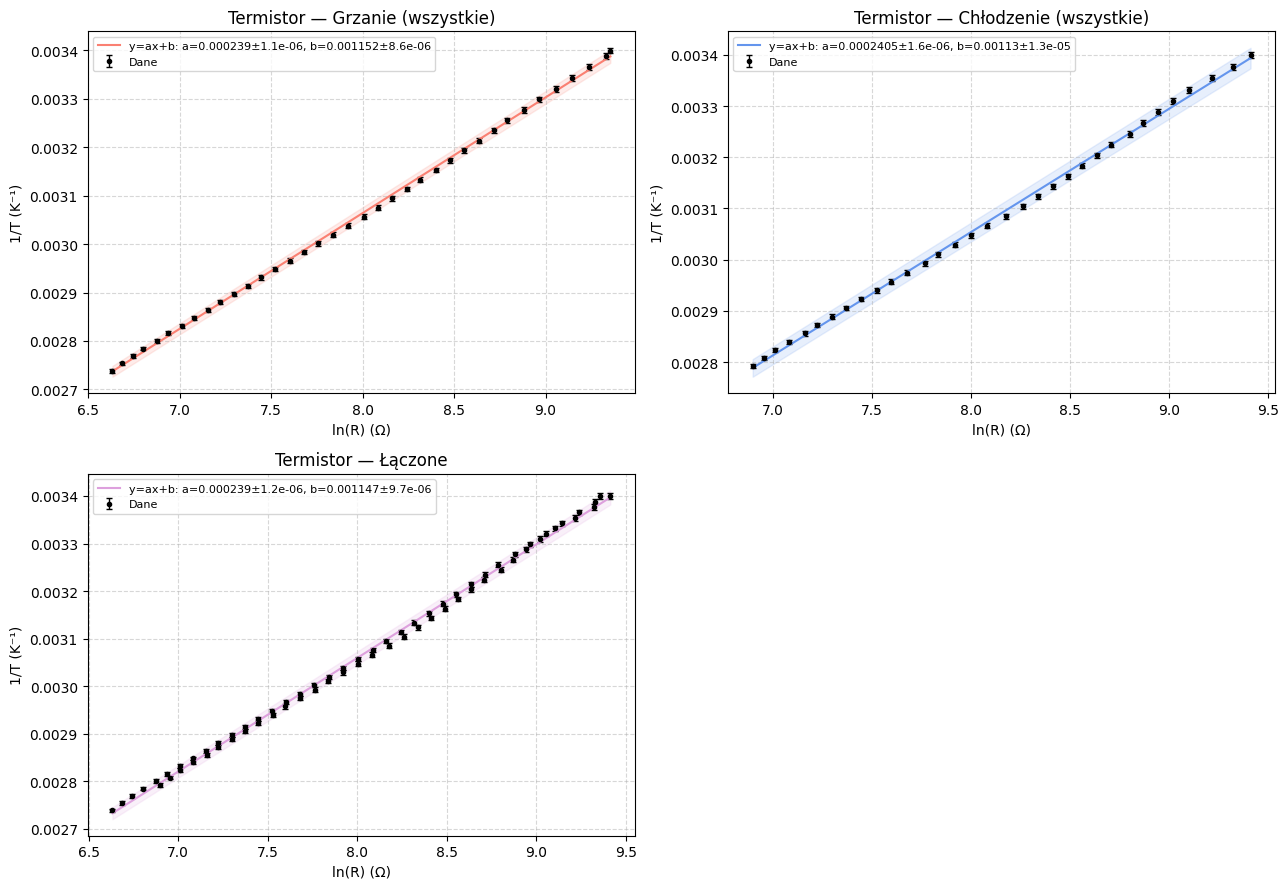

In [17]:
# Wykres 1 — Termistor: pełne zestawy i łączone
make_figure([
    (thermistor_heating, "ln_resistance", "inv_temperature", "temperature", None, "ln(R) (Ω)", "1/T (K⁻¹)", "Termistor — Grzanie (wszystkie)", "red",    "salmon"),
    (thermistor_cooling, "ln_resistance", "inv_temperature", "temperature", None, "ln(R) (Ω)", "1/T (K⁻¹)", "Termistor — Chłodzenie (wszystkie)", "blue",   "cornflowerblue"),
    (th_combined,        "ln_resistance", "inv_temperature", "temperature", None, "ln(R) (Ω)", "1/T (K⁻¹)", "Termistor — Łączone",                "purple", "plum"),
], filename="wykres1_termistor_pelne")

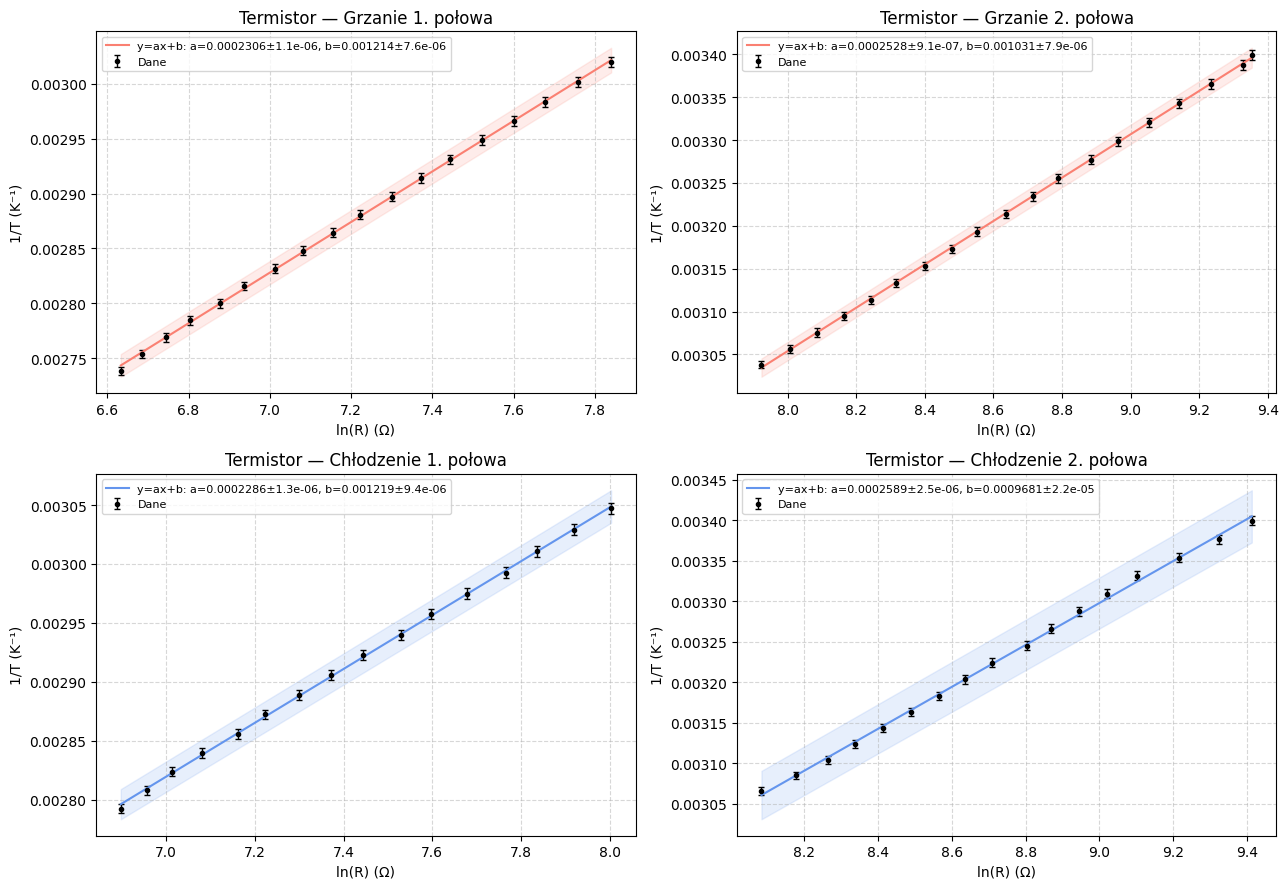

In [18]:
# Wykres 2 — Termistor: połowy zestawów grzania i chłodzenia
make_figure([
    (th_h1, "ln_resistance", "inv_temperature", "temperature", None, "ln(R) (Ω)", "1/T (K⁻¹)", "Termistor — Grzanie 1. połowa",    "red",  "salmon"),
    (th_h2, "ln_resistance", "inv_temperature", "temperature", None, "ln(R) (Ω)", "1/T (K⁻¹)", "Termistor — Grzanie 2. połowa",    "red",  "salmon"),
    (th_c1, "ln_resistance", "inv_temperature", "temperature", None, "ln(R) (Ω)", "1/T (K⁻¹)", "Termistor — Chłodzenie 1. połowa", "blue", "cornflowerblue"),
    (th_c2, "ln_resistance", "inv_temperature", "temperature", None, "ln(R) (Ω)", "1/T (K⁻¹)", "Termistor — Chłodzenie 2. połowa", "blue", "cornflowerblue"),
], filename="wykres2_termistor_polowy")

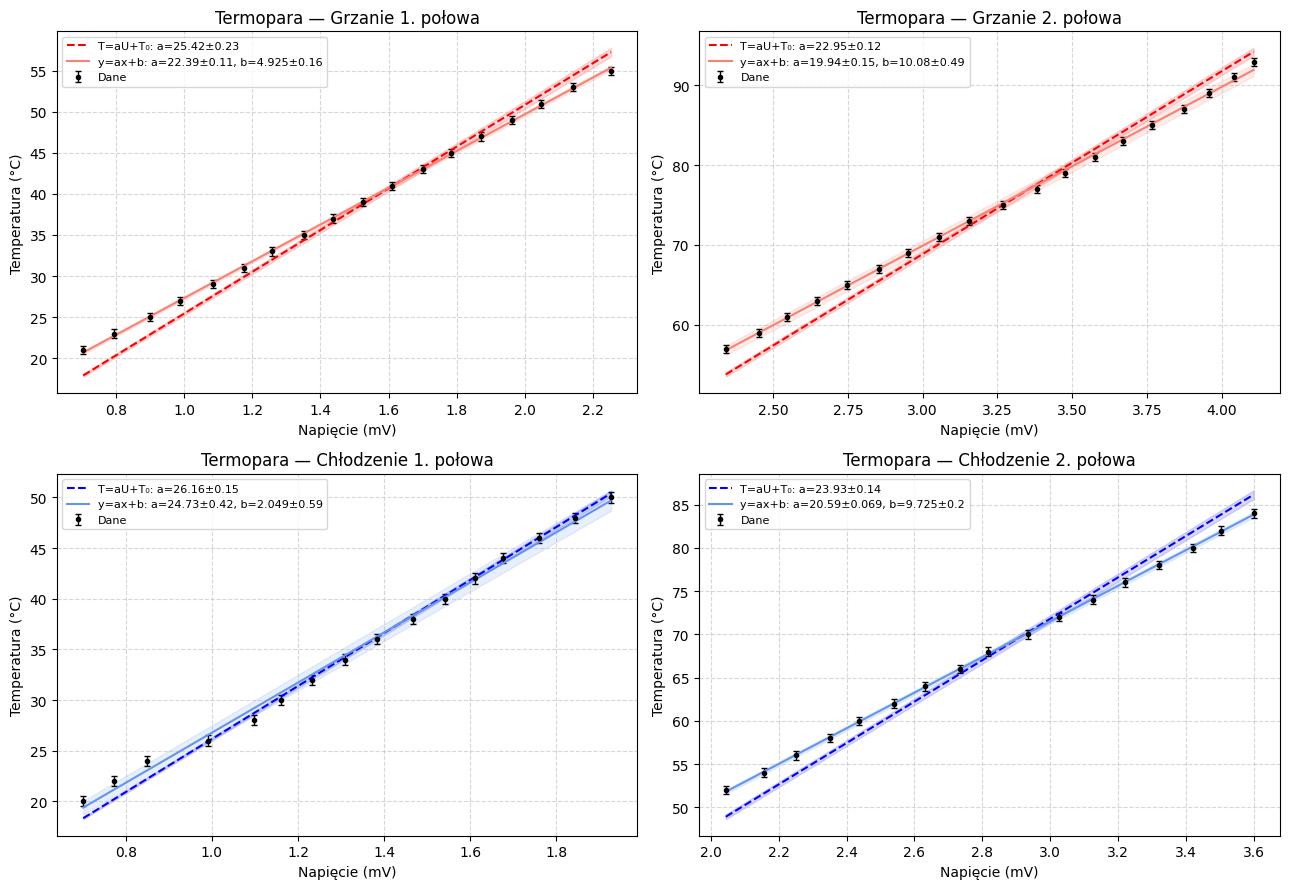

In [19]:
# Wykres 3 — Termopara: połowy zestawów grzania i chłodzenia
make_figure([
    (tc_h1, "voltage", "temperature", None, T0, "Napięcie (mV)", "Temperatura (°C)", "Termopara — Grzanie 1. połowa",    "red",  "salmon"),
    (tc_h2, "voltage", "temperature", None, T0, "Napięcie (mV)", "Temperatura (°C)", "Termopara — Grzanie 2. połowa",    "red",  "salmon"),
    (tc_c1, "voltage", "temperature", None, T0, "Napięcie (mV)", "Temperatura (°C)", "Termopara — Chłodzenie 1. połowa", "blue", "cornflowerblue"),
    (tc_c2, "voltage", "temperature", None, T0, "Napięcie (mV)", "Temperatura (°C)", "Termopara — Chłodzenie 2. połowa", "blue", "cornflowerblue"),
], filename="wykres3_termopara_polowy")

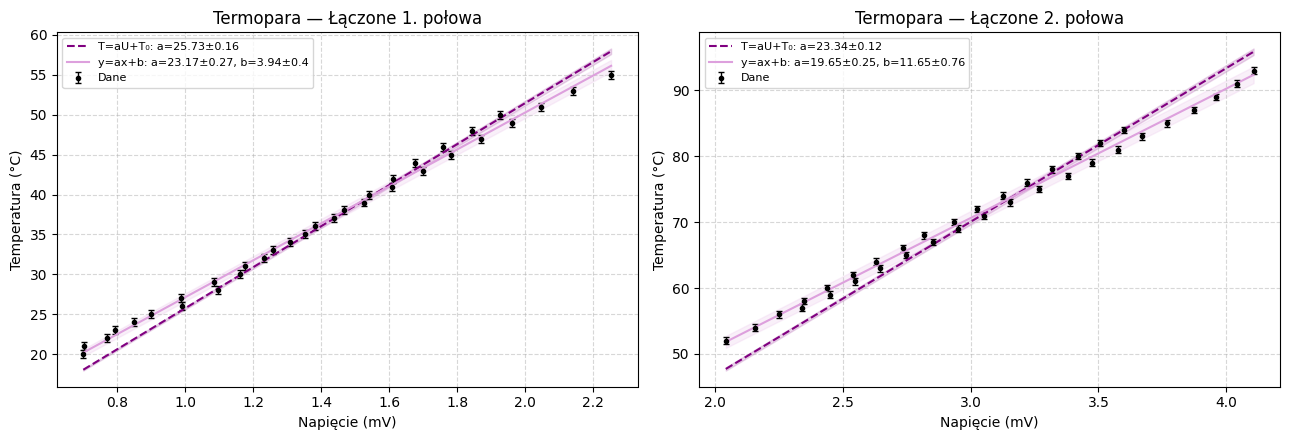

In [20]:
# Wykres 4 — Termopara: połączone połowy
make_figure([
    (tc_combined_1, "voltage", "temperature", None, T0, "Napięcie (mV)", "Temperatura (°C)", "Termopara — Łączone 1. połowa", "purple", "plum"),
    (tc_combined_2, "voltage", "temperature", None, T0, "Napięcie (mV)", "Temperatura (°C)", "Termopara — Łączone 2. połowa", "purple", "plum"),
], filename="wykres4_termopara_laczone")

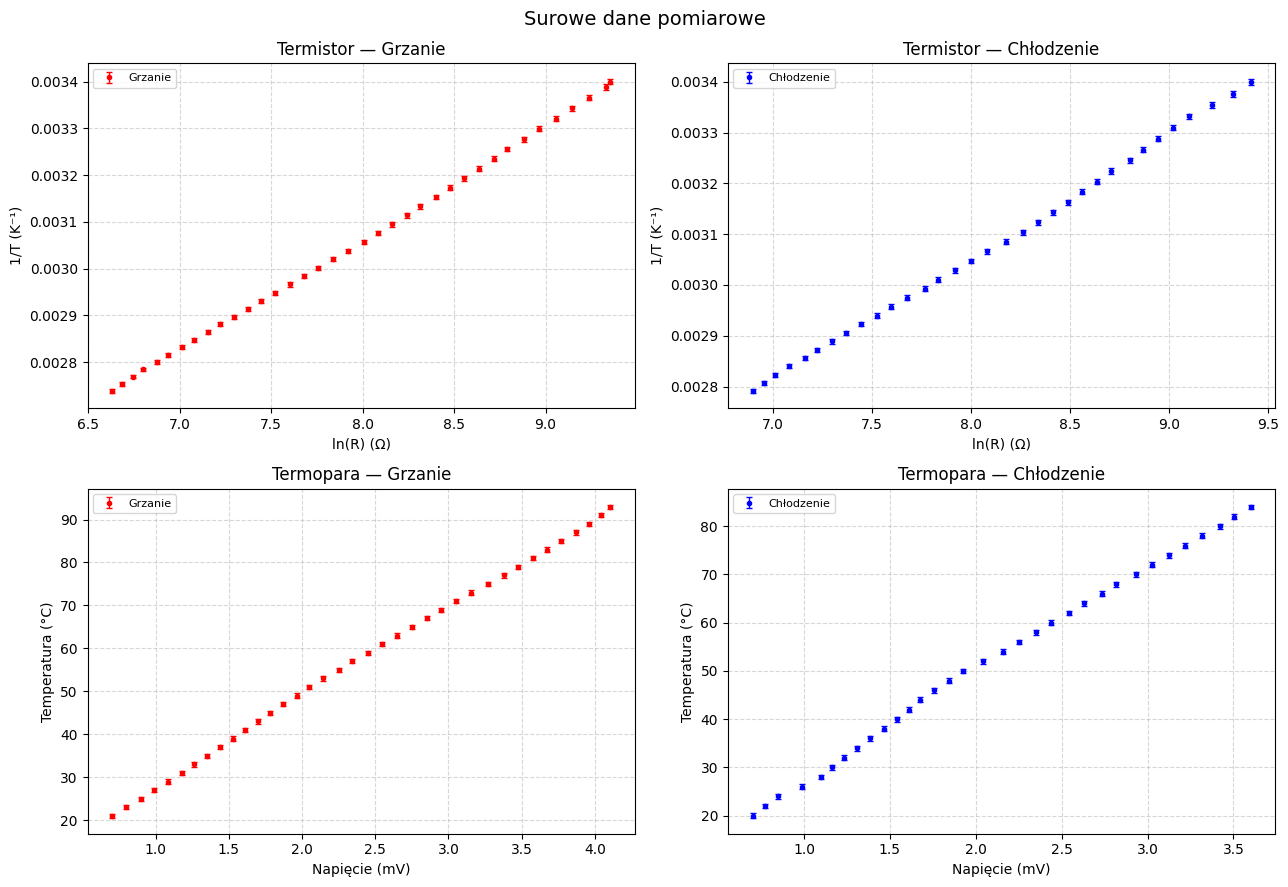

In [21]:
# Wykres surowych danych pomiarowych — bez regresji
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Termistor — Grzanie
ax = axes[0, 0]
x = thermistor_heating["ln_resistance"].values
y = thermistor_heating["inv_temperature"].values
yerr = dT / thermistor_heating["temperature"].values**2
ax.errorbar(x, y, yerr=yerr, fmt="o", color="red",
            capsize=2, elinewidth=1, capthick=1, markersize=3, label="Grzanie")
ax.set_xlabel("ln(R) (Ω)")
ax.set_ylabel("1/T (K⁻¹)")
ax.set_title("Termistor — Grzanie")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

# Termistor — Chłodzenie
ax = axes[0, 1]
x = thermistor_cooling["ln_resistance"].values
y = thermistor_cooling["inv_temperature"].values
yerr = dT / thermistor_cooling["temperature"].values**2
ax.errorbar(x, y, yerr=yerr, fmt="o", color="blue",
            capsize=2, elinewidth=1, capthick=1, markersize=3, label="Chłodzenie")
ax.set_xlabel("ln(R) (Ω)")
ax.set_ylabel("1/T (K⁻¹)")
ax.set_title("Termistor — Chłodzenie")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

# Termopara — Grzanie
ax = axes[1, 0]
x = thermocouple_heating["voltage"].values
y = thermocouple_heating["temperature"].values
ax.errorbar(x, y, yerr=dT, fmt="o", color="red",
            capsize=2, elinewidth=1, capthick=1, markersize=3, label="Grzanie")
ax.set_xlabel("Napięcie (mV)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Termopara — Grzanie")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

# Termopara — Chłodzenie
ax = axes[1, 1]
x = thermocouple_cooling["voltage"].values
y = thermocouple_cooling["temperature"].values
ax.errorbar(x, y, yerr=dT, fmt="o", color="blue",
            capsize=2, elinewidth=1, capthick=1, markersize=3, label="Chłodzenie")
ax.set_xlabel("Napięcie (mV)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Termopara — Chłodzenie")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Surowe dane pomiarowe", fontsize=14)
plt.tight_layout()
fig.savefig("wykres0_surowe_dane.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# ── Przerwa energetyczna W z regresji termistora ──────────────────────────────
# Model: R = R₀ · exp(W / 2kT)
# Linearyzacja: 1/T = (2k/W) · ln(R) + const
# Nachylenie a = 2k/W  →  W = 2k/a,  u(W) = 2k/a² · u(a)

k_B_eV = 8.617333e-5   # eV/K
k_B_J  = 1.380649e-23  # J/K

datasets_therm = [
    ("Grzanie (wszystkie)",    thermistor_heating),
    ("Chłodzenie (wszystkie)", thermistor_cooling),
    ("Łączone",                th_combined),
    ("Grzanie 1. połowa",      th_h1),
    ("Grzanie 2. połowa",      th_h2),
    ("Chłodzenie 1. połowa",   th_c1),
    ("Chłodzenie 2. połowa",   th_c2),
]

rows = []
for label, df in datasets_therm:
    a, da, b, db = fit_linear(df["ln_resistance"], df["inv_temperature"])
    W_eV  = 2 * k_B_eV / a
    uW_eV = 2 * k_B_eV / a**2 * da
    W_J   = 2 * k_B_J  / a
    uW_J  = 2 * k_B_J  / a**2 * da
    rows.append({
        "Zestaw":      label,
        "a (K⁻¹)":    a,
        "u(a) (K⁻¹)": da,
        "W (eV)":      W_eV,
        "u(W) (eV)":   uW_eV,
        "W (J)":       W_J,
        "u(W) (J)":    uW_J,
    })

wyniki = pd.DataFrame(rows).set_index("Zestaw")

print("Przerwa energetyczna W termistora (model: 1/T = a·ln R + b, W = 2k_B/a)\n")
print(f"{'Zestaw':<28} {'a (K⁻¹)':>12}  {'u(a)':>10}  {'W (eV)':>10}  {'u(W) eV':>10}  {'W (J)':>12}  {'u(W) J':>12}")
print("-" * 100)
for row in rows:
    print(f"{row['Zestaw']:<28} {row['a (K⁻¹)']:>12.4g}  {row['u(a) (K⁻¹)']:>10.2g}  "
          f"{row['W (eV)']:>10.4g}  {row['u(W) (eV)']:>10.2g}  "
          f"{row['W (J)']:>12.4g}  {row['u(W) (J)']:>12.2g}")

display(wyniki.style.format({
    "a (K⁻¹)":    "{:.4g}",
    "u(a) (K⁻¹)": "{:.2g}",
    "W (eV)":      "{:.4g}",
    "u(W) (eV)":   "{:.2g}",
    "W (J)":       "{:.4g}",
    "u(W) (J)":    "{:.2g}",
}).set_caption("Przerwa energetyczna W termistora"))

Przerwa energetyczna W termistora (model: 1/T = a·ln R + b, W = 2k_B/a)

Zestaw                            a (K⁻¹)        u(a)      W (eV)     u(W) eV         W (J)        u(W) J
----------------------------------------------------------------------------------------------------
Grzanie (wszystkie)              0.000239     1.1e-06       0.721      0.0033     1.155e-19       5.2e-22
Chłodzenie (wszystkie)          0.0002405     1.6e-06      0.7166      0.0048     1.148e-19       7.7e-22
Łączone                          0.000239     1.2e-06       0.721      0.0036     1.155e-19       5.8e-22
Grzanie 1. połowa               0.0002306     1.1e-06      0.7474      0.0034     1.197e-19       5.5e-22
Grzanie 2. połowa               0.0002528     9.1e-07      0.6816      0.0024     1.092e-19       3.9e-22
Chłodzenie 1. połowa            0.0002286     1.3e-06       0.754      0.0042     1.208e-19       6.7e-22
Chłodzenie 2. połowa            0.0002589     2.5e-06      0.6657      0.0065     1.

,a (K⁻¹),u(a) (K⁻¹),W (eV),u(W) (eV),W (J),u(W) (J)
Zestaw,,,,,,
Grzanie (wszystkie),0.000239,1.1e-06,0.721,0.0033,1.155e-19,5.2e-22
Chłodzenie (wszystkie),0.0002405,1.6e-06,0.7166,0.0048,1.148e-19,7.7e-22
Łączone,0.000239,1.2e-06,0.721,0.0036,1.155e-19,5.8e-22
Grzanie 1. połowa,0.0002306,1.1e-06,0.7474,0.0034,1.197e-19,5.5e-22
Grzanie 2. połowa,0.0002528,9.1e-07,0.6816,0.0024,1.092e-19,3.9e-22
Chłodzenie 1. połowa,0.0002286,1.3e-06,0.754,0.0042,1.208e-19,6.7e-22
Chłodzenie 2. połowa,0.0002589,2.5e-06,0.6657,0.0065,1.067e-19,1e-21


In [23]:
# ── Tabela zbiorcza wszystkich regresji ───────────────────────────────────────
summary_rows = []

# Termistor — tylko dopasowanie swobodne (1/T vs ln R)
therm_sets = [
    ("Grzanie",    "wszystkie", thermistor_heating),
    ("Chłodzenie", "wszystkie", thermistor_cooling),
    ("Łączone",    "—",         th_combined),
    ("Grzanie",    "1. połowa", th_h1),
    ("Grzanie",    "2. połowa", th_h2),
    ("Chłodzenie", "1. połowa", th_c1),
    ("Chłodzenie", "2. połowa", th_c2),
]
for dataset, half, df in therm_sets:
    a, da, b, db = fit_linear(df["ln_resistance"], df["inv_temperature"])
    W_eV  = 2 * k_B_eV / a
    uW_eV = 2 * k_B_eV / a**2 * da
    summary_rows.append({
        "Czujnik":      "Termistor",
        "Zestaw":       dataset,
        "Połowa":       half,
        "Model":        "1/T = a·ln(R) + b",
        "Zakotwiczony": "Nie",
        "a ± u(a)":     f"{a:.4g} ± {da:.2g}",
        "b ± u(b)":     f"{b:.4g} ± {db:.2g}",
        "W ± u(W) (eV)": f"{W_eV:.4g} ± {uW_eV:.2g}",
    })

# Termopara — dopasowanie zakotwiczone i swobodne (T vs U, T w °C)
tc_sets = [
    ("Grzanie",    "1. połowa", tc_h1),
    ("Grzanie",    "2. połowa", tc_h2),
    ("Chłodzenie", "1. połowa", tc_c1),
    ("Chłodzenie", "2. połowa", tc_c2),
    ("Łączone",    "1. połowa", tc_combined_1),
    ("Łączone",    "2. połowa", tc_combined_2),
]
for dataset, half, df in tc_sets:
    # Zakotwiczone: T = aU + T₀  (T₀ = 0°C)
    a, da = fit_fixed_intercept(df["voltage"], df["temperature"], T0)
    summary_rows.append({
        "Czujnik":      "Termopara",
        "Zestaw":       dataset,
        "Połowa":       half,
        "Model":        "T = aU + T₀",
        "Zakotwiczony": "Tak (T₀ = 0°C)",
        "a ± u(a)":     f"{a:.4g} ± {da:.2g}",
        "b ± u(b)":     "—",
        "W ± u(W) (eV)": "—",
    })
    # Swobodne: T = aU + b
    a, da, b, db = fit_linear(df["voltage"], df["temperature"])
    summary_rows.append({
        "Czujnik":      "Termopara",
        "Zestaw":       dataset,
        "Połowa":       half,
        "Model":        "T = aU + b",
        "Zakotwiczony": "Nie",
        "a ± u(a)":     f"{a:.4g} ± {da:.2g}",
        "b ± u(b)":     f"{b:.4g} ± {db:.2g}",
        "W ± u(W) (eV)": "—",
    })

tabela = pd.DataFrame(summary_rows)
display(
    tabela.style
    .set_caption("Zestawienie wszystkich regresji")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    .hide(axis="index")
)

Czujnik,Zestaw,Połowa,Model,Zakotwiczony,a ± u(a),b ± u(b),W ± u(W) (eV)
Termistor,Grzanie,wszystkie,1/T = a·ln(R) + b,Nie,0.000239 ± 1.1e-06,0.001152 ± 8.6e-06,0.721 ± 0.0033
Termistor,Chłodzenie,wszystkie,1/T = a·ln(R) + b,Nie,0.0002405 ± 1.6e-06,0.00113 ± 1.3e-05,0.7166 ± 0.0048
Termistor,Łączone,—,1/T = a·ln(R) + b,Nie,0.000239 ± 1.2e-06,0.001147 ± 9.7e-06,0.721 ± 0.0036
Termistor,Grzanie,1. połowa,1/T = a·ln(R) + b,Nie,0.0002306 ± 1.1e-06,0.001214 ± 7.6e-06,0.7474 ± 0.0034
Termistor,Grzanie,2. połowa,1/T = a·ln(R) + b,Nie,0.0002528 ± 9.1e-07,0.001031 ± 7.9e-06,0.6816 ± 0.0024
Termistor,Chłodzenie,1. połowa,1/T = a·ln(R) + b,Nie,0.0002286 ± 1.3e-06,0.001219 ± 9.4e-06,0.754 ± 0.0042
Termistor,Chłodzenie,2. połowa,1/T = a·ln(R) + b,Nie,0.0002589 ± 2.5e-06,0.0009681 ± 2.2e-05,0.6657 ± 0.0065
Termopara,Grzanie,1. połowa,T = aU + T₀,Tak (T₀ = 0°C),25.42 ± 0.23,—,—
Termopara,Grzanie,1. połowa,T = aU + b,Nie,22.39 ± 0.11,4.925 ± 0.16,—
Termopara,Grzanie,2. połowa,T = aU + T₀,Tak (T₀ = 0°C),22.95 ± 0.12,—,—


In [24]:
# ── Współczynniki regresji — wartości liczbowe z niepewnościami ───────────────

coeff_rows = []

# --- Termistor: 1/T = a·ln(R) + b ---
for label, df in [
    ("Grzanie (wszystkie)",    thermistor_heating),
    ("Chłodzenie (wszystkie)", thermistor_cooling),
    ("Łączone",                th_combined),
    ("Grzanie 1. połowa",      th_h1),
    ("Grzanie 2. połowa",      th_h2),
    ("Chłodzenie 1. połowa",   th_c1),
    ("Chłodzenie 2. połowa",   th_c2),
]:
    a, da, b, db = fit_linear(df["ln_resistance"], df["inv_temperature"])
    coeff_rows.append({
        "Czujnik": "Termistor",
        "Zestaw":  label,
        "Model":   "1/T = a·ln(R) + b",
        "a":  a,  "u(a)": da,
        "b":  b,  "u(b)": db,
    })

# --- Termopara: T = a·U + T₀ (zakotwiczone) ---
for label, df in [
    ("Grzanie 1. połowa",    tc_h1),
    ("Grzanie 2. połowa",    tc_h2),
    ("Chłodzenie 1. połowa", tc_c1),
    ("Chłodzenie 2. połowa", tc_c2),
    ("Łączone 1. połowa",    tc_combined_1),
    ("Łączone 2. połowa",    tc_combined_2),
]:
    a, da = fit_fixed_intercept(df["voltage"], df["temperature"], T0)
    coeff_rows.append({
        "Czujnik": "Termopara",
        "Zestaw":  label,
        "Model":   "T = a·U + T₀ (T₀=0°C)",
        "a":  a,  "u(a)": da,
        "b":  T0, "u(b)": float("nan"),   # zakotwiczone — b ustalone
    })

# --- Termopara: T = a·U + b (swobodne) ---
for label, df in [
    ("Grzanie 1. połowa",    tc_h1),
    ("Grzanie 2. połowa",    tc_h2),
    ("Chłodzenie 1. połowa", tc_c1),
    ("Chłodzenie 2. połowa", tc_c2),
    ("Łączone 1. połowa",    tc_combined_1),
    ("Łączone 2. połowa",    tc_combined_2),
]:
    a, da, b, db = fit_linear(df["voltage"], df["temperature"])
    coeff_rows.append({
        "Czujnik": "Termopara",
        "Zestaw":  label,
        "Model":   "T = a·U + b",
        "a":  a,  "u(a)": da,
        "b":  b,  "u(b)": db,
    })

coeff_df = pd.DataFrame(coeff_rows)

# Formatowanie: 4 cyfry znaczące dla wartości, 2 dla niepewności
fmt = {
    "a":    "{:.4g}",
    "u(a)": "{:.2g}",
    "b":    "{:.4g}",
    "u(b)": "{:.2g}",
}

display(
    coeff_df.style
    .format(fmt, na_rep="—")
    .set_caption("Współczynniki regresji z niepewnościami")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
        {"selector": "th",      "props": [("text-align", "center")]},
        {"selector": "td",      "props": [("text-align", "right")]},
    ])
    .hide(axis="index")
)

Czujnik,Zestaw,Model,a,u(a),b,u(b)
Termistor,Grzanie (wszystkie),1/T = a·ln(R) + b,0.000239,1.1e-06,0.001152,8.6e-06
Termistor,Chłodzenie (wszystkie),1/T = a·ln(R) + b,0.0002405,1.6e-06,0.00113,1.3e-05
Termistor,Łączone,1/T = a·ln(R) + b,0.000239,1.2e-06,0.001147,9.7e-06
Termistor,Grzanie 1. połowa,1/T = a·ln(R) + b,0.0002306,1.1e-06,0.001214,7.6e-06
Termistor,Grzanie 2. połowa,1/T = a·ln(R) + b,0.0002528,9.1e-07,0.001031,7.9e-06
Termistor,Chłodzenie 1. połowa,1/T = a·ln(R) + b,0.0002286,1.3e-06,0.001219,9.4e-06
Termistor,Chłodzenie 2. połowa,1/T = a·ln(R) + b,0.0002589,2.5e-06,0.0009681,2.2e-05
Termopara,Grzanie 1. połowa,T = a·U + T₀ (T₀=0°C),25.42,0.23,0,—
Termopara,Grzanie 2. połowa,T = a·U + T₀ (T₀=0°C),22.95,0.12,0,—
Termopara,Chłodzenie 1. połowa,T = a·U + T₀ (T₀=0°C),26.16,0.15,0,—


In [25]:
# ── Współczynnik Seebecka α termopary ─────────────────────────────────────────
# Model: T = a·U + const  →  α = dU/dT = 1/a  [mV/°C]
# Propagacja niepewności: u(α) = u(a) / a²
# Przeliczenie: α [µV/°C] = α [mV/°C] × 1000

tc_sets_labeled = [
    ("Grzanie",    "1. połowa", tc_h1),
    ("Grzanie",    "2. połowa", tc_h2),
    ("Chłodzenie", "1. połowa", tc_c1),
    ("Chłodzenie", "2. połowa", tc_c2),
    ("Łączone",    "1. połowa", tc_combined_1),
    ("Łączone",    "2. połowa", tc_combined_2),
]

alpha_rows_anch = []
alpha_rows_free = []

for dataset, half, df in tc_sets_labeled:
    label = f"{dataset} — {half}"

    # --- Model zakotwiczony: T = a·U + T₀ ---
    a, da = fit_fixed_intercept(df["voltage"], df["temperature"], T0)
    alpha_mV   = 1.0 / a
    u_alpha_mV = da / a**2
    alpha_rows_anch.append({
        "Zestaw":       label,
        "a (°C/mV)":   a,
        "u(a) (°C/mV)": da,
        "α (mV/°C)":   alpha_mV,
        "u(α) (mV/°C)": u_alpha_mV,
        "α (µV/°C)":   alpha_mV * 1e3,
        "u(α) (µV/°C)": u_alpha_mV * 1e3,
    })

    # --- Model swobodny: T = a·U + b ---
    a, da, b, db = fit_linear(df["voltage"], df["temperature"])
    alpha_mV   = 1.0 / a
    u_alpha_mV = da / a**2
    alpha_rows_free.append({
        "Zestaw":       label,
        "a (°C/mV)":   a,
        "u(a) (°C/mV)": da,
        "α (mV/°C)":   alpha_mV,
        "u(α) (mV/°C)": u_alpha_mV,
        "α (µV/°C)":   alpha_mV * 1e3,
        "u(α) (µV/°C)": u_alpha_mV * 1e3,
    })

# Zachowaj połączone dla weighted avg
alpha_rows = alpha_rows_anch + alpha_rows_free

fmt_alpha = {
    "a (°C/mV)":    "{:.4g}",
    "u(a) (°C/mV)": "{:.2g}",
    "α (mV/°C)":    "{:.4g}",
    "u(α) (mV/°C)": "{:.2g}",
    "α (µV/°C)":    "{:.4g}",
    "u(α) (µV/°C)": "{:.2g}",
}
table_styles = [
    {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
    {"selector": "th",      "props": [("text-align", "center")]},
    {"selector": "td",      "props": [("text-align", "right")]},
]

print("Współczynnik Seebecka α (model zakotwiczony: T = a·U + T₀, α = 1/a)\n")
wyniki_anch = pd.DataFrame(alpha_rows_anch).set_index("Zestaw")
display(wyniki_anch.style.format(fmt_alpha)
        .set_caption("α — model zakotwiczony (T = a·U + T₀)")
        .set_table_styles(table_styles))

print("\nWspółczynnik Seebecka α (model swobodny: T = a·U + b, α = 1/a)\n")
wyniki_free = pd.DataFrame(alpha_rows_free).set_index("Zestaw")
display(wyniki_free.style.format(fmt_alpha)
        .set_caption("α — model swobodny (T = a·U + b)")
        .set_table_styles(table_styles))

Współczynnik Seebecka α (model zakotwiczony: T = a·U + T₀, α = 1/a)



,a (°C/mV),u(a) (°C/mV),α (mV/°C),u(α) (mV/°C),α (µV/°C),u(α) (µV/°C)
Zestaw,,,,,,
Grzanie — 1. połowa,25.42,0.23,0.03934,0.00036,39.34,0.36
Grzanie — 2. połowa,22.95,0.12,0.04358,0.00023,43.58,0.23
Chłodzenie — 1. połowa,26.16,0.15,0.03823,0.00022,38.23,0.22
Chłodzenie — 2. połowa,23.93,0.14,0.04179,0.00025,41.79,0.25
Łączone — 1. połowa,25.73,0.16,0.03887,0.00024,38.87,0.24
Łączone — 2. połowa,23.34,0.12,0.04284,0.00022,42.84,0.22



Współczynnik Seebecka α (model swobodny: T = a·U + b, α = 1/a)



,a (°C/mV),u(a) (°C/mV),α (mV/°C),u(α) (mV/°C),α (µV/°C),u(α) (µV/°C)
Zestaw,,,,,,
Grzanie — 1. połowa,22.39,0.11,0.04467,0.00021,44.67,0.21
Grzanie — 2. połowa,19.94,0.15,0.05015,0.00037,50.15,0.37
Chłodzenie — 1. połowa,24.73,0.42,0.04044,0.00069,40.44,0.69
Chłodzenie — 2. połowa,20.59,0.069,0.04857,0.00016,48.57,0.16
Łączone — 1. połowa,23.17,0.27,0.04316,0.00051,43.16,0.51
Łączone — 2. połowa,19.65,0.25,0.05088,0.00064,50.88,0.64


In [26]:
# ── Średnie ważone końcowe: α i W ─────────────────────────────────────────────
# Waga: wᵢ = 1/u(xᵢ)²
# Średnia ważona: x̄ = Σ(wᵢ·xᵢ) / Σwᵢ
# Niepewność:    u(x̄) = 1/√(Σwᵢ)

def weighted_avg(values, uncertainties):
    v = np.asarray(values, dtype=float)
    u = np.asarray(uncertainties, dtype=float)
    w = 1.0 / u**2
    mean = np.dot(w, v) / w.sum()
    u_mean = 1.0 / np.sqrt(w.sum())
    return mean, u_mean

# --- α: model zakotwiczony ---
avg_anch, u_avg_anch = weighted_avg(
    [r["α (µV/°C)"] for r in alpha_rows_anch],
    [r["u(α) (µV/°C)"] for r in alpha_rows_anch],
)
# --- α: model swobodny ---
avg_free, u_avg_free = weighted_avg(
    [r["α (µV/°C)"] for r in alpha_rows_free],
    [r["u(α) (µV/°C)"] for r in alpha_rows_free],
)

print("Współczynnik Seebecka α — średnia ważona (wᵢ = 1/u²ᵢ):")
print(f"  model zakotwiczony:  ᾱ = {avg_anch:.4g} ± {u_avg_anch:.2g}  µV/°C"
      f"  ({avg_anch/1e3:.4g} ± {u_avg_anch/1e3:.2g}  mV/°C)")
print(f"  model swobodny:      ᾱ = {avg_free:.4g} ± {u_avg_free:.2g}  µV/°C"
      f"  ({avg_free/1e3:.4g} ± {u_avg_free/1e3:.2g}  mV/°C)")

# --- W: ze wszystkich zestawów termistora ---
W_avg_eV, uW_avg_eV = weighted_avg(
    [r["W (eV)"] for r in rows],
    [r["u(W) (eV)"] for r in rows],
)
W_avg_J, uW_avg_J = weighted_avg(
    [r["W (J)"] for r in rows],
    [r["u(W) (J)"] for r in rows],
)

print("\nPrzerwa energetyczna W — średnia ważona (wᵢ = 1/u²ᵢ):")
print(f"  W̄ = {W_avg_eV:.4g} ± {uW_avg_eV:.2g}  eV")
print(f"  W̄ = {W_avg_J:.4g} ± {uW_avg_J:.2g}  J")

Współczynnik Seebecka α — średnia ważona (wᵢ = 1/u²ᵢ):
  model zakotwiczony:  ᾱ = 40.9 ± 0.099  µV/°C  (0.0409 ± 9.9e-05  mV/°C)
  model swobodny:      ᾱ = 47.14 ± 0.11  µV/°C  (0.04714 ± 0.00011  mV/°C)

Przerwa energetyczna W — średnia ważona (wᵢ = 1/u²ᵢ):
  W̄ = 0.7138 ± 0.0014  eV
  W̄ = 1.144e-19 ± 2.2e-22  J
